# Titanic Dataset: Feature Engineering and Logistic Regression Optimization
**Author:** Bridget  
**Course:** DAML
***


### Step One: Library Imports
*We import  scientific computing libraries i.e **pandas** for data manipulation and structured dataframes, **numpy** for numerical array operations, and **matplotlib** for static data visualizations.*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Step Two: Loading the Dataset
*We load the Titanic dataset from a local CSV file into a pandas DataFrame object named `df_titanic` to begin our analysis.*



In [2]:
df_titanic =pd.read_csv("titanic.csv")

### Step Three: Initial Feature Inspection
*We display the first five rows of our loaded dataset to visually inspect columns, features, structural patterns, and initial structural layouts.*


In [3]:
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step Four: Structural Schema Overview
*We execute the `.info()` summary method to assess operational data types, examine total  non-null entry distributions, and flag initial missing value footprints across the features.*


In [4]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


### Step Five (a): Assign Missing Age Values for "Master"
*We create a boolean mask to filter passengers containing the title "Master" in their name, calculate their mean age, and use that specific mean to fill their missing age records.*



In [5]:
#1.create the boolean mask for rows containing master in the Name column
mask = df_titanic["Name"].str.contains("Master", na = False)
#2. Calculate the mean age specifically for those rows
master_age_mean = df_titanic.loc[mask,"Age"].mean()
#3.Fill missing Age values only for rows mathcing the mask
df_titanic.loc[mask,"Age"] = df_titanic.loc[mask,"Age"].fillna(master_age_mean)

### Step Five (b): Assign Missing Age Values for "Miss"
*We isolate passengers with the title "Miss" using string matching, find their group mean age, and handle their missing null entries systematically.*


In [6]:
# 1. Create the boolean mask for miss
mask_miss = df_titanic["Name"].str.contains("Miss", na=False)

# 2. Calculate the mean age specifically for those rows
miss_age_mean = df_titanic.loc[mask_miss, "Age"].mean()

# 3. Fill missing Age values only for rows matching the mask
df_titanic.loc[mask_miss, "Age"] = df_titanic.loc[mask_miss, "Age"].fillna(miss_age_mean)


### Step Five (c): Assign Missing Age Values for "Mrs"
*We generate a mask targeting rows with the title "Mrs", compute the group's mean age, and substitute that specific value into the missing age fields.*


In [7]:
# 1. Create the boolean mask for Mrs
mask_mrs = df_titanic["Name"].str.contains("Mrs", na=False)

# 2. Calculate the mean age specifically for those rows
mrs_age_mean = df_titanic.loc[mask_mrs, "Age"].mean()

# 3. Fill missing Age values only for rows matching the mask
df_titanic.loc[mask_mrs, "Age"] = df_titanic.loc[mask_mrs, "Age"].fillna(mrs_age_mean)



### Step Five (d): Assign Missing 'Embarked' Values Using existing Records
*According to historical data on [Encyclopedia Titanica](https://encyclopedia-titanica.org), first-class passenger Mrs. Martha Evelyn Stone and her maid Miss Rose Amélie Icard boarded the ship at Southampton. We filter specifically for these names to accurately impute their missing records with 'S'.*


In [8]:
# 1. Filter specifically for Mrs. Stone and Miss Icard using partial string matches
mask_stone = df_titanic['Name'].str.contains('Stone, Mrs.', na=False)
mask_icard = df_titanic['Name'].str.contains('Icard', na=False)

# 2. Directly assign 'S' to the 'Embarked' column for those specific rows
df_titanic.loc[mask_stone, 'Embarked'] = 'S'
df_titanic.loc[mask_icard, 'Embarked'] = 'S'


### Step Five (e): Imputing Missing 'Fare' Values Using Historical Records
*Data analysis revealed a single missing value in the `Fare` column. Historical records from [Encyclopedia Titanica](https://encyclopedia-titanica.org) confirm this record belongs to Mr. Thomas Storey, a third-class passenger and crossing fireman who was given passage on the ship. Because he was traveling on a service pass, his true ticket fare was £0.0. We filter explicitly for his name to accurately impute this record.*


In [9]:


# 1. Create a mask to locate Mr. Thomas Storey
mask_storey = df_titanic['Name'].str.contains('Storey, Mr. Thomas', na=False)

# 2. Directly assign £0.0 to his missing Fare record
df_titanic.loc[mask_storey, 'Fare'] = 0.0


### Step Five (f): Advanced Conditional Group attribution for Missing Ages
*Instead of utilizing a broad global median, we engineer a smarter feature imputation strategy. We extract individual passenger titles (e.g., Master, Miss, Mr, Mrs) directly from the `Name` field, partition the data into title-based subpopulations, and dynamically calculate and apply localized group medians to our missing age values.*


In [10]:
df_titanic['Title'] = df_titanic['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

title_mapping = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Mrs", "Countess": "Mrs", "Dona": "Mrs",
    "Capt": "Mr", "Col": "Mr", "Don": "Mr", "Jonkheer": "Mr", 
    "Major": "Mr", "Rev": "Mr", "Sir": "Mr", "Dr": "Mr"
}
df_titanic['Title'] = df_titanic['Title'].replace(title_mapping)

title_medians = df_titanic.groupby('Title')['Age'].median()
print("Calculated Subpopulation Age Medians:\n", title_medians)

for title in title_medians.index:
    mask_title_null = (df_titanic['Title'] == title) & (df_titanic['Age'].isnull())
    df_titanic.loc[mask_title_null, 'Age'] = title_medians[title]

df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())


Calculated Subpopulation Age Medians:
 Title
Master     5.482642
Miss      21.774238
Mr        30.000000
Mrs       36.804598
Name: Age, dtype: float64


### Step Six: Separate Features (X)
*We drop the target column `Survived` from our dataset to create our feature matrix `X`.*


In [11]:
X = df_titanic.drop(["Survived"], axis=1)


### Step Seven: Create Target Variable (y)
*We isolate the `Survived` column to create our target vector `y` for model training.*


In [12]:
y=df_titanic["Survived"]

### Step Eight: Verify Feature Matrix
*We display the first five rows of our feature matrix `X` to confirm the `Survived` column was successfully dropped.*


In [13]:
X.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


### Step Nine: Inspect Target Class Overview
*We view the initial entries of our target array `y` to ensure that our output array aligns properly with the structural boundaries of our feature matrix.*


In [14]:
y.head(5)

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

### Step Ten: Visualize Class Balance and Distribution
*We compute the frequency distribution of our target variable using a bar plot to check for any severe class imbalances between the surviving and non-surviving passenger groups.*


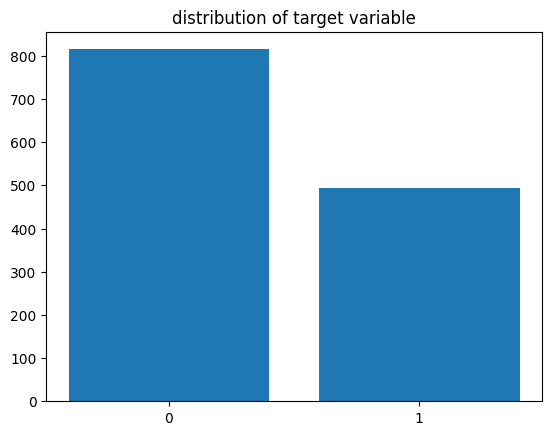

In [15]:
x = y.value_counts()
plt.bar(x.index, x)
plt.gca().set_xticks([0, 1])
plt.title("distribution of target variable")
plt.show()



### Step Eleven: Package Environment Verification
*We execute an environmental check and installation protocol to guarantee that the scikit-learn dependency is actively available within our kernel workspace.*


In [16]:
%pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Step Twelve: Import Label Encoding Transformer
*We import the foundational `LabelEncoder` class from the scikit-learn preprocessing suite to prepare for text-to-numeric categorical conversions.*


In [17]:
from sklearn.preprocessing import LabelEncoder

### Step Thirteen: Apply Label Encoding Baseline to Object Columns
*We instantiate a processing dictionary loop that iterates through all categorical object features, encoding text metrics into ordinal integers to establish our initial baseline framework.*


In [18]:
train = pd.DataFrame()
label = LabelEncoder()

for c in X.columns:
    if X[c].dtype == "object":
        train[c] = label.fit_transform(X[c].astype(str))
    else:
        train[c] = X[c]

    

### Step Fourteen: Import Core Modeling and Evaluation Dependencies
*We source our primary scikit-learn modules for modeling, including dataset train-test slicing tools, cross-validation utilities, metric scoring APIs, and the Logistic Regression estimator.*


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

### Step Fifteen: Establish Logistic Regression Evaluation Helper Function
*We declare a reusable scoring function that isolates training and testing subsets under standard random seeding constraints and handles core logistic modeling execution.*


In [20]:
def logistic(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
    
    lr = LogisticRegression(max_iter=5000)
    
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    print("Accuracy: ", accuracy_score(y_test, y_pred))





### Step Sixteen: Run the Baseline Model Using Label Encoding
*We make a copy of our label-encoded data and filter for only the numeric columns. Then, we run our logistic regression function to get our baseline accuracy score.*



In [21]:
X_baseline = train.copy()

X_baseline_clean = X_baseline.select_dtypes(include=['int64', 'float64'])

logistic(X_baseline_clean, y)




Accuracy:  0.8473282442748091


### Step Seventeen: Import One-Hot Encoding Transformer
*We import the `OneHotEncoder` preprocessing class from the scikit-learn library to transition from ordinal integers to explicit binary feature representations for categorical nominal variables.*


In [22]:
from sklearn.preprocessing import OneHotEncoder

### Step Eighteen: Run the Improved Model Using One-Hot Encoding
*We use One-Hot Encoding on both the 'Sex' and 'Embarked' columns so the model treats them as clean binary options. Then, we combine these new encoded features side-by-side with our clean numeric data and run the model again to see the final accuracy.*





In [24]:

encoder_sex = OneHotEncoder(sparse_output=False)
one_hot_sex_df = pd.DataFrame(encoder_sex.fit_transform(X[['Sex']]), columns=encoder_sex.get_feature_names_out(['Sex']))

encoder_embarked = OneHotEncoder(sparse_output=False)
one_hot_emb_df = pd.DataFrame(encoder_embarked.fit_transform(X[['Embarked']]), columns=encoder_embarked.get_feature_names_out(['Embarked']))

numeric_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X_clean_numeric = X[numeric_cols].copy()

train_full_ohe = pd.concat([
    X_clean_numeric.reset_index(drop=True),
    one_hot_sex_df.reset_index(drop=True),
    one_hot_emb_df.reset_index(drop=True)
], axis=1)

logistic(train_full_ohe, y)




Accuracy:  0.851145038167939


### Summary and Conclusion

I successfully tested two different ways to handle categorical data and missing values to see how they affect our Logistic Regression model:

* **First Try (Label Encoding):** By turning our text data into basic numbers, the model reached a baseline accuracy of **84.73%**. 
* **Fixing Missing Data:** Instead of just filling missing values with a general average, I used a smarter approach. I googled historical records to fix specific missing entries for fare and embarkation. I also used a group lookups to give missing ages a realistic number based on their title (like Master or Miss) rather than a flat average. 
* **Final Upgrade (One-Hot Encoding):** When I converted 'Sex' and 'Embarked' into one-hot dummy variables, it cleaned up the data structure and pushed our final accuracy up to **85.11%**. 

Overall, doing specific data cleanup and using One-Hot Encoding gave the model cleaner features to learn from and resulted in a higher accuracy score.



